# Project Overview & Dataset

## Problem Statement
The objective of this project is to develop a machine learning model capable of automatically categorizing IT support tickets across multiple languages.

## Dataset Description
This project uses the Multilingual Customer Support Tickets dataset.

# Project Setup

In [1]:
import kagglehub
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

/home/jano/src/python/IT-ticket-classifier/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Download dataset

In [2]:
# Download latest version

DATA_FOLDER = "../data"

FILE_NAME = "IT Support Ticket Data.csv"

path = kagglehub.dataset_download("parthpatil256/it-support-ticket-data")

print("Dataset downloaded to cache:", path)

if not os.path.exists(DATA_FOLDER):
    os.mkdir(DATA_FOLDER)
    print(f"Folder created: {DATA_FOLDER}")

src_path = os.path.join(path, FILE_NAME)
dest_path = os.path.join(DATA_FOLDER, FILE_NAME)

if not os.path.exists(dest_path):
    if os.path.exists(src_path):
        print(f"Copying '{FILE_NAME}' to the project folder...")
        shutil.copy(src_path, dest_path)
        print("Copy finished successfully.")
    else:
        print(f"File '{FILE_NAME}' not found in the downloaded files.")
else:
    print(f"File '{FILE_NAME}' already exists in {DATA_FOLDER}. Skipping copy.")

# Verification
print(f"Files in {DATA_FOLDER}: {os.listdir(DATA_FOLDER)}")

100%|██████████| 3.19M/3.19M [00:00<00:00, 5.79MB/s]

Extracting files...


Dataset downloaded to cache: /home/jano/.cache/kagglehub/datasets/parthpatil256/it-support-ticket-data/versions/1
Copying 'IT Support Ticket Data.csv' to the project folder...
Copy finished successfully.
Files in ../data: ['aa_dataset-tickets-multi-lang-5-2-50-version.csv', 'IT Support Ticket Data.csv']


# Load and Exploratory Data Analysis

## Basic Dataset Inspection

In [13]:
df_original = pd.read_csv(dest_path, index_col=0)

# basic info
print("Dataset info:")
print(df_original.info())
print("#"*50)
print("\nFirst 5 rows:")
display(df_original.head(5))
print("\nDataset shape:")
print(df_original.shape)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Body        29650 non-null  str  
 1   Department  29651 non-null  str  
 2   Priority    29651 non-null  str  
 3   Tags        29651 non-null  str  
dtypes: str(4)
memory usage: 926.7 KB
None
##################################################

First 5 rows:


,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."



Dataset shape:
(29651, 4)


## Distribution of Objective Variables

In [ ]:
print("--- Department distribution in percentage ---")
display((df_original["Department"].value_counts(normalize=True)*100).round(2))

print("\n--- Priority distribution in percentage ---")
display((df_original["Priority"].value_counts(normalize=True)*100).round(2))

--- Queue Distribution in percentage ---


Department
Technical Support                  29.06
Product Support                    18.68
Customer Service                   15.12
IT Support                         11.80
Billing and Payments               10.18
Returns and Exchanges               4.95
Service Outages and Maintenance     3.90
Sales and Pre-Sales                 2.98
Human Resources                     1.92
General Inquiry                     1.41
Name: proportion, dtype: float64


--- Priority Distribution in percentage ---


Priority
medium    40.90
high      38.82
low       20.28
Name: proportion, dtype: float64

## Missing Data Detection

Text representation:

Unnamed: 0    0
Department    0
Priority      0
Tags          0
Body          1
dtype: int64

Graphic representation


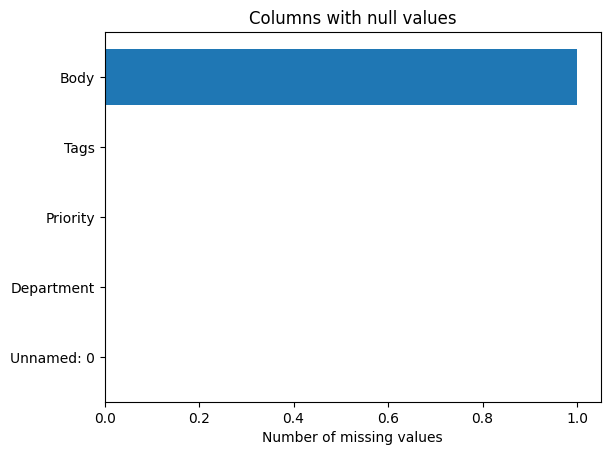

In [6]:
null_sum = df_original.isnull().sum()
null_sum = null_sum.sort_values(ascending=True)
print("Text representation:\n")
print(null_sum)

print("\nGraphic representation")
plt.barh(null_sum.index,null_sum.values)
plt.title("Columns with null values")
plt.xlabel('Number of missing values')
plt.show()

## Objective Variable Distribution

### Department Distribution

Text representation:

Department
Technical Support                  8617
Product Support                    5539
Customer Service                   4482
IT Support                         3500
Billing and Payments               3017
Returns and Exchanges              1467
Service Outages and Maintenance    1157
Sales and Pre-Sales                 885
Human Resources                     568
General Inquiry                     419
Name: count, dtype: int64

Graphic representation


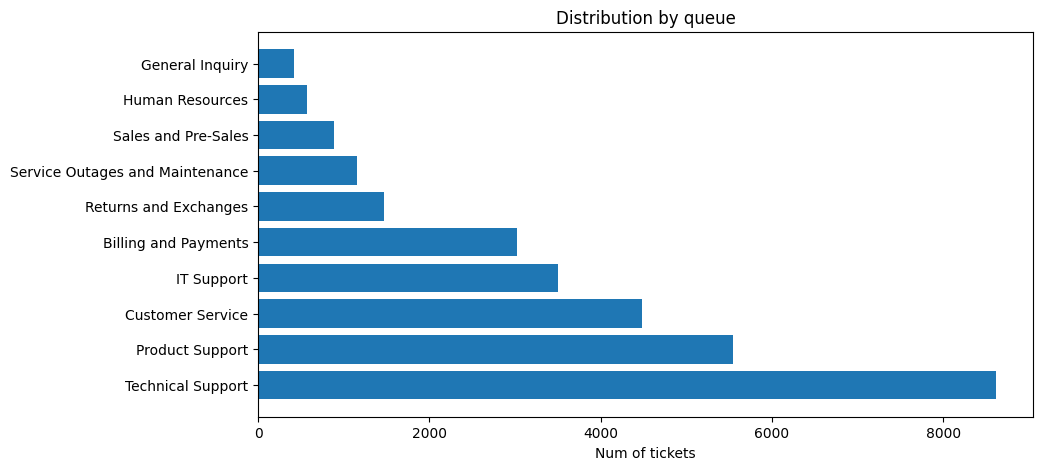

In [7]:
department_tickets = df_original["Department"].value_counts()
print("Text representation:\n")
print(department_tickets)

print("\nGraphic representation")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(department_tickets.index,department_tickets.values)
ax.set_title("Distribution by queue")
ax.set_xlabel("Num of tickets")
plt.show()

### Priority Distribution

Text representation:

Priority
medium    12126
high      11512
low        6013
Name: count, dtype: int64

Graphic representation


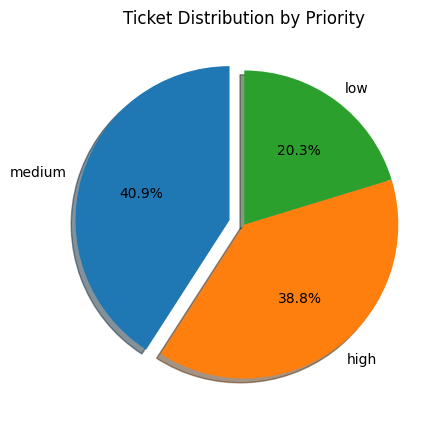

In [8]:
priority_tickets = df_original["Priority"].value_counts()
print("Text representation:\n")
print(priority_tickets)

print("\nGraphic representation")
fig, ax = plt.subplots(figsize=(10, 5))
explode = (0.1, 0, 0)
ax.pie(priority_tickets.values, labels=priority_tickets.index, explode=explode,
        shadow=True, autopct='%1.1f%%', startangle=90)

plt.title("Ticket Distribution by Priority")
plt.show()

## Text Length

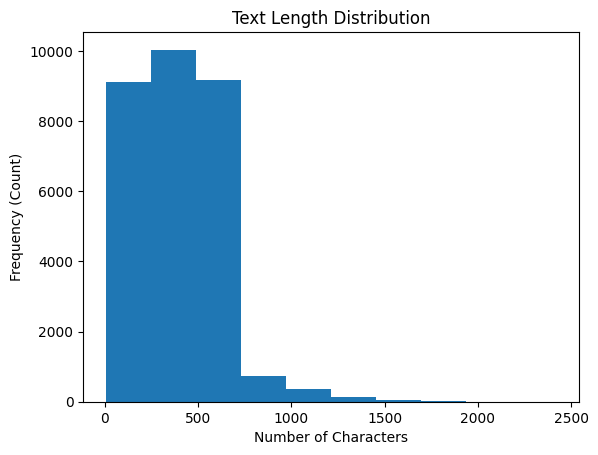

In [11]:
fig, ax = plt.subplots()
ax.hist(df_original["Body"].str.len())
ax.set_title("Text Length Distribution")
ax.set_xlabel("Number of Characters")
ax.set_ylabel("Frequency (Count)")
plt.show()

# Data Preprocessing

In [ ]:
# create a copy from the original df to mantain the original dataset untouch
df = df_original.copy()

display(df.info())

display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Body        29650 non-null  str  
 1   Department  29651 non-null  str  
 2   Priority    29651 non-null  str  
 3   Tags        29651 non-null  str  
dtypes: str(4)
memory usage: 926.7 KB


None

,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


In [ ]:
# Fill null values in the subject column


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   28587 non-null  object
 1   body      28587 non-null  object
 2   queue     28587 non-null  object
 3   priority  28587 non-null  object
dtypes: object(4)
memory usage: 893.5+ KB


In [18]:
# Concatenate 'subject' and 'body' to provide the model with the full context of the ticket
df["full_text"] = df["subject"] + ". " + df["body"]

rng = np.random.default_rng()

rand_num = rng.integers(0, len(df))

df["full_text"].iloc[rand_num]

"Request for Support Interruption. Dear Customer Service, <br><br>We are writing to report an interruption in our services. The digital marketing tools, which are crucial for our brand's growth, are affected. The issue seems to have been caused by a server failure that was triggered by a recent software update. Our team has attempted to resolve the issue by restarting the affected devices and verifying the connections, but unfortunately, the problem persists.<br><br>We appreciate your attention to this matter and hope that you can address the issue as soon as possible and provide us with the necessary instructions to fix the problem."

In [19]:
# Clean literal escape sequences (e.g., \n, \r) and remove extra whitespaces
df["full_text"] = df["full_text"].str.replace(r'\\[a-z]|<br>', " ", regex=True)

df["full_text"] = df["full_text"].str.replace(r'\s+', ' ', regex=True).str.strip()

df["full_text"].iloc[rand_num]

"Request for Support Interruption. Dear Customer Service, We are writing to report an interruption in our services. The digital marketing tools, which are crucial for our brand's growth, are affected. The issue seems to have been caused by a server failure that was triggered by a recent software update. Our team has attempted to resolve the issue by restarting the affected devices and verifying the connections, but unfortunately, the problem persists. We appreciate your attention to this matter and hope that you can address the issue as soon as possible and provide us with the necessary instructions to fix the problem."

In [20]:
# Target Variable Encoding
le = LabelEncoder()

df["encoded_queue"] = le.fit_transform(df["queue"])

print(le.classes_)

['Billing and Payments' 'Customer Service' 'General Inquiry'
 'Human Resources' 'IT Support' 'Product Support' 'Returns and Exchanges'
 'Sales and Pre-Sales' 'Service Outages and Maintenance'
 'Technical Support']


In [23]:
# split dataset on train and test
X = df["full_text"]

y = df["encoded_queue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("-> Train shape:")
print(X_train.shape)
print(y_train.shape)

print("\n-> Test shape:")
print(X_test.shape)
print(y_test.shape)

-> Train shape:
(22869,)
(22869,)

-> Test shape:
(5718,)
(5718,)
